LIBRARIES

In [48]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

INPUTS

In [49]:
IMG_HEIGHT=227
IMG_WIDTH =227
IMG_CHANNELS = 3
CLASS_NAMES = ["lilly", "lotus", "orchid", "sunflower", "tulip"]

In [50]:
train_dataset= tf.keras.utils.image_dataset_from_directory(
    r"C:\My Folder\Projects\Computer_Vision\flower_images\train",
    labels ='inferred',
    label_mode = 'int',
    batch_size=16,
    image_size=(IMG_HEIGHT, IMG_WIDTH)
)

val_dataset= tf.keras.utils.image_dataset_from_directory(
    r"C:\My Folder\Projects\Computer_Vision\flower_images\val",
    labels ='inferred',
    label_mode = 'int',
    batch_size=16,
    image_size=(IMG_HEIGHT, IMG_WIDTH)
)
normalize = tf.keras.layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalize(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalize(x), y))

Found 3000 files belonging to 5 classes.
Found 1000 files belonging to 5 classes.


NETWORK ARCHITECTURE

In [51]:
def FireModule(squeeze_ch, expand_ch, s):

    squeeze = tf.keras.layers.Conv2D(squeeze_ch, kernel_size=1, activation='relu')(s)

    expand1 = tf.keras.layers.Conv2D(expand_ch, kernel_size=1, activation='relu')(squeeze)
    expand2 = tf.keras.layers.Conv2D(expand_ch, kernel_size=3, padding='same', activation='relu')(squeeze)

    out = tf.keras.layers.Concatenate(axis=-1)([expand1, expand2])

    return out


In [52]:

inputs=keras.layers.Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))

x = keras.layers.Conv2D(filters=96, kernel_size=7, strides=2, padding='same')(inputs)
x = keras.layers.MaxPool2D(pool_size=3, strides=2)(x)

x = FireModule(16, 64, x)
x = FireModule(16, 64, x)
x = FireModule(32, 128, x)

x = keras.layers.MaxPool2D(pool_size=3, strides=2)(x)

x = FireModule(32, 128, x)
x = FireModule(48, 192, x)
x = FireModule(48, 192, x)
x = FireModule(64, 256, x)

x = keras.layers.MaxPool2D(pool_size=3, strides=2)(x)

x = FireModule(64, 256, x)

x = keras.layers.Conv2D(filters=1000, kernel_size=1, strides=1, padding='same')(x)
x = keras.layers.AveragePooling2D(pool_size=13, strides=1)(x)

x= keras.layers.Flatten()(x)

outputs =  keras.layers.Dense(5, activation='softmax')(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 227, 227,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_151 (Conv2D) │ (None, 114, 114,  │     14,208 │ input_layer_9[0]… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_20    │ (None, 56, 56,    │          0 │ conv2d_151[0][0]  │
│ (MaxPooling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_152 (Conv2D) │ (None, 56, 56,    │      1,552 │ max_pooling2d_20… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_153 (Conv2D) │ (None, 56, 56,    │      1,088 │ conv2d_152[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_154 (Conv2D) │ (None, 56, 56,    │      9,280 │ conv2d_152[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_45      │ (None, 56, 56,    │          0 │ conv2d_153[0][0], │
│ (Concatenate)       │ 128)              │            │ conv2d_154[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_155 (Conv2D) │ (None, 56, 56,    │      2,064 │ concatenate_45[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_156 (Conv2D) │ (None, 56, 56,    │      1,088 │ conv2d_155[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_157 (Conv2D) │ (None, 56, 56,    │      9,280 │ conv2d_155[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_46      │ (None, 56, 56,    │          0 │ conv2d_156[0][0], │
│ (Concatenate)       │ 128)              │            │ conv2d_157[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_158 (Conv2D) │ (None, 56, 56,    │      4,128 │ concatenate_46[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_159 (Conv2D) │ (None, 56, 56,    │      4,224 │ conv2d_158[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_160 (Conv2D) │ (None, 56, 56,    │     36,992 │ conv2d_158[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_47      │ (None, 56, 56,    │          0 │ conv2d_159[0][0], │
│ (Concatenate)       │ 256)              │            │ conv2d_160[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_21    │ (None, 27, 27,    │          0 │ concatenate_47[0… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_161 (Conv2D) │ (None, 27, 27,    │      8,224 │ max_pooling2d_21

 Total params: 1,253,429 (4.78 MB)

 Trainable params: 1,253,429 (4.78 MB)

 Non-trainable params: 0 (0.00 B)

TRAINING

In [53]:
EPOCHS=10
history = model.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 79s 398ms/step - accuracy: 0.2037 - loss: 1.6124 - val_accuracy: 0.2000 - val_loss: 1.6103
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 77s 406ms/step - accuracy: 0.1897 - loss: 1.6118 - val_accuracy: 0.2000 - val_loss: 1.6099
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 77s 407ms/step - accuracy: 0.1800 - loss: 1.6115 - val_accuracy: 0.2000 - val_loss: 1.6096
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 77s 408ms/step - accuracy: 0.1920 - loss: 1.6106 - val_accuracy: 0.2000 - val_loss: 1.6096
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 77s 409ms/step - accuracy: 0.1837 - loss: 1.6103 - val_accuracy: 0.2000 - val_loss: 1.6095
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 77s 406ms/step - accuracy: 0.1963 - loss: 1.6103 - val_accuracy: 0.2000 - val_loss: 1.6095
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 77s 408ms/step - accuracy: 0.1923 - loss: 1.6101 - val_accuracy: 0.2000 - val_loss: 1.6095
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 77s 407ms/step - accuracy: 0.1923 - loss: 1

PLOTTING

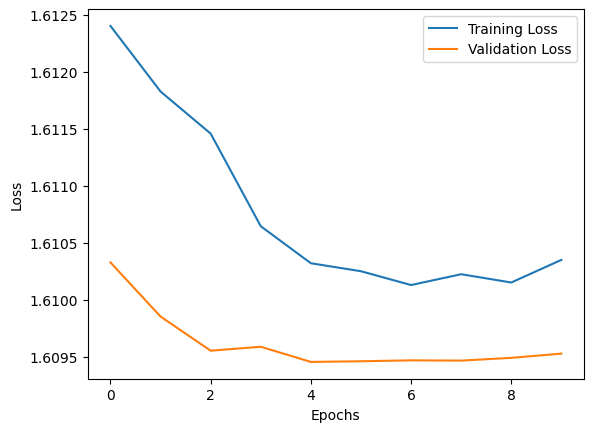

In [54]:
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

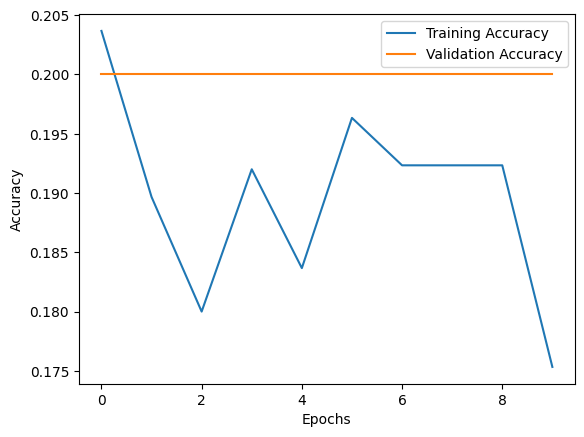

In [55]:
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()